# v5 — Análise de DOS Projetada — Fase 4

**Notebook:** `v5_dos_candidatos.ipynb`  
**Projeto:** Triagem computacional de materiais para aplicações fotovoltaicas  
**Fase anterior:** Fase 3 — Modelos de ML (v4_modelos_ml.ipynb + v4_secao8_otimizacao.ipynb)

---

## Objetivos desta fase

1. **Seção 1** — Setup e carregamento dos candidatos finais das Fases 3
2. **Seção 2** — Verificação de cobertura DOS no Materials Project
3. **Seção 3** — Análise DOS candidatos PV: caráter orbital VBM/CBM
4. **Seção 4** — Análise DOS candidatos IBSC: estados dentro do gap
5. **Seção 5** — Correção empírica gap DFT → experimental
6. **Seção 6** — Estrutura de bandas — top 5 candidatos por janela
7. **Seção 7** — Tabela final consolidada para o artigo

---

## Nota metodológica — limitações da DOS do Materials Project

A análise DOS desta fase usa dados pré-calculados do Materials Project (nível GGA/GGA+U).  
Isso implica as seguintes limitações documentadas:

- **Subestimação de gap**: ~30–40% para perovskitas duplas (referência: Cs₂AgBiBr₆ DFT 1.35 → exp 2.2 eV)
- **Estados 4f de terras-raras**: aparecem artificialmente dentro do gap no nível GGA — não representam estados físicos reais de banda intermediária. Identificar e documentar explicitamente.
- **Materiais GGA+U (candidatos IBSC com Mn/Fe/Co/V)**: o parâmetro U afeta a posição dos estados d. A DOS reflete o U aplicado pelo MP, não necessariamente o U ótimo para cada composto.
- **Comparação direta GGA vs HSE06**: não disponível para a maioria dos candidatos. Os 3 candidatos HSE06 na lista PV (SmBi₂BrO₄, ErBi₂ClO₄, TmBi₂IO₄) são exceções valiosas.

**Posicionamento no artigo**: análise DOS do MP como caracterização eletrônica exploratória que motiva cálculos híbridos futuros, não como resultado quantitativo definitivo.

---
# Seção 1 — Setup e carregamento dos candidatos

In [1]:
# Instalação de dependências (rodar uma vez por sessão Colab)
!pip install mp-api pymatgen python-dotenv matminer -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

# API do Materials Project
from mp_api.client import MPRester

# pymatgen — manipulação de estruturas e DOS
from pymatgen.electronic_structure.dos import CompleteDos
from pymatgen.electronic_structure.core import OrbitalType, Spin
from pymatgen.core import Element

warnings.filterwarnings('ignore')

# Colab Secrets
try:
    from google.colab import userdata
    os.environ['MP_API_KEY'] = userdata.get('MP_API_KEY')
    print('API key carregada via Colab Secrets.')
except Exception:
    print('Colab Secrets não disponível — usando MP_API_KEY do ambiente.')

MP_API_KEY = os.environ.get('MP_API_KEY')
assert MP_API_KEY, 'MP_API_KEY não encontrada. Verificar Colab Secrets.'

print('Setup concluído.')

API key carregada via Colab Secrets.
Setup concluído.


In [8]:
# ── Carregamento das listas de candidatos exportadas na Fase 3 ──────────────
#
# Arquivos gerados em v4_secao8_otimizacao.ipynb:
#   data/fase3/top_candidatos_pv_final.csv   — 72 candidatos PV, threshold=0.48
#   data/fase3/top_candidatos_ibsc_final.csv — 60 candidatos IBSC

# ── Colab: injetar chave e importar módulos ───────────────────────────────────
import os, sys
from google.colab import userdata
os.environ["MP_API_KEY"] = userdata.get("MP_API_KEY")
!git clone https://github.com/douglasbaquiao/materials-solar-ml.git 2>/dev/null || git -C materials-solar-ml pull
sys.path.insert(0, "/content/materials-solar-ml/src")


CAMINHO_PV   = 'materials-solar-ml/data/fase3/top_candidatos_pv_final.csv'
CAMINHO_IBSC = 'materials-solar-ml/data/fase3/top_candidatos_ibsc_pd.csv'

df_pv   = pd.read_csv(CAMINHO_PV)
df_ibsc = pd.read_csv(CAMINHO_IBSC)

print(f'Candidatos PV carregados:   {len(df_pv)}')
print(f'Candidatos IBSC carregados: {len(df_ibsc)}')
print()
print('Colunas disponíveis:')
print(df_pv.columns.tolist())

Already up to date.
Candidatos PV carregados:   72
Candidatos IBSC carregados: 60

Colunas disponíveis:
['material_id', 'formula', 'band_gap', 'energy_above_hull', 'is_gap_direct', 'regime_calc', 'proba_pv_calibrado']


In [7]:
import os

data_path = '/content/materials-solar-ml/data/fase3/'

if os.path.exists(data_path):
    print(f"Contents of {data_path}:")
    for item in os.listdir(data_path):
        print(f"- {item}")
else:
    print(f"Directory not found: {data_path}")

Contents of /content/materials-solar-ml/data/fase3/:
- top_candidatos_pv_pd.csv
- shap_importancia_pv_pd.csv
- read.me
- top_candidatos_pv_final.csv
- validacao_hse06.csv
- top_candidatos_ibsc_pd.csv


In [9]:
# ── Flags e constantes para o notebook ──────────────────────────────────────

# Fator de correção empírico GGA → experimental para PD halogenadas
# Referência: Cs₂AgBiBr₆ — DFT 1.35 eV → experimental 2.2 eV → fator ~1.63
# ATENÇÃO: fator médio aproximado — varia por composição. Usar apenas como
# estimativa de ordem de grandeza. Documentar incerteza no artigo.
FATOR_CORRECAO_GGA_PD = 1.63

# Janelas de gap (DFT ampliadas)
JANELA_PV_MIN,   JANELA_PV_MAX   = 0.7, 2.0   # eV
JANELA_IBSC_MIN, JANELA_IBSC_MAX = 1.4, 3.2   # eV

# Janelas corrigidas (estimativa experimental)
JANELA_PV_CORR_MIN,   JANELA_PV_CORR_MAX   = 1.0, 1.8   # S-Q
JANELA_IBSC_CORR_MIN, JANELA_IBSC_CORR_MAX = 1.8, 2.6   # Luque & Martí 1997

# Threshold para estados dentro do gap (IBSC)
# Estados com densidade > LIMIAR_ESTADOS_GAP são candidatos a banda intermediária
LIMIAR_ESTADOS_GAP = 0.05  # estados/eV — ajustar conforme inspeção visual

# Paleta de cores por orbital (padrão para figuras do artigo)
CORES_ORBITAL = {
    's':   '#4878CF',
    'p':   '#6ACC65',
    'd':   '#D65F5F',
    'f':   '#B47CC7',
    'total': '#888888'
}

print('Constantes definidas.')
print(f'  Fator correção GGA→exp (PD): {FATOR_CORRECAO_GGA_PD}')
print(f'  Janela PV DFT: {JANELA_PV_MIN}–{JANELA_PV_MAX} eV')
print(f'  Janela IBSC DFT: {JANELA_IBSC_MIN}–{JANELA_IBSC_MAX} eV')

Constantes definidas.
  Fator correção GGA→exp (PD): 1.63
  Janela PV DFT: 0.7–2.0 eV
  Janela IBSC DFT: 1.4–3.2 eV


---
# Seção 2 — Verificação de cobertura DOS no Materials Project

Antes de qualquer análise, é necessário verificar quais candidatos têm DOS
disponível no MP. A cobertura não é universal — especialmente para compostos
com terras-raras e estruturas menos estudadas.

In [10]:
# ── Verificação de cobertura: quais candidatos têm DOS disponível ────────────

ids_pv   = df_pv['material_id'].tolist()
ids_ibsc = df_ibsc['material_id'].tolist()
ids_todos = list(set(ids_pv + ids_ibsc))

com_dos_pv   = []
sem_dos_pv   = []
com_dos_ibsc = []
sem_dos_ibsc = []

with MPRester(MP_API_KEY) as mpr:
    for mid in ids_pv:
        try:
            dos = mpr.get_dos_by_material_id(mid)
            if dos is not None:
                com_dos_pv.append(mid)
            else:
                sem_dos_pv.append(mid)
        except Exception:
            sem_dos_pv.append(mid)

    for mid in ids_ibsc:
        try:
            dos = mpr.get_dos_by_material_id(mid)
            if dos is not None:
                com_dos_ibsc.append(mid)
            else:
                sem_dos_ibsc.append(mid)
        except Exception:
            sem_dos_ibsc.append(mid)

print('── Cobertura DOS ──────────────────────────────────')
print(f'PV   — com DOS: {len(com_dos_pv):3d} / {len(ids_pv)}  '
      f'({100*len(com_dos_pv)/len(ids_pv):.0f}%)')
print(f'IBSC — com DOS: {len(com_dos_ibsc):3d} / {len(ids_ibsc)}  '
      f'({100*len(com_dos_ibsc)/len(ids_ibsc):.0f}%)')
print()

if sem_dos_pv:
    print(f'PV sem DOS ({len(sem_dos_pv)}): {sem_dos_pv[:10]}')
if sem_dos_ibsc:
    print(f'IBSC sem DOS ({len(sem_dos_ibsc)}): {sem_dos_ibsc[:10]}')

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

...

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

── Cobertura DOS ──────────────────────────────────
PV   — com DOS:  63 / 72  (88%)
IBSC — com DOS:  42 / 60  (70%)

PV sem DOS (9): ['mp-1112544', 'mp-1219602', 'mp-1212006', 'mp-1205717', 'mp-1228863', 'mp-1213740', 'mp-1113707', 'mp-1111665', 'mp-1210483']
IBSC sem DOS (18): ['mp-17805', 'mp-17918', 'mp-1225934', 'mp-1228886', 'mp-567433', 'mp-1113068', 'mp-1219598', 'mp-1225938', 'mp-1226043', 'mp-1228899']


In [11]:
# ── Filtrar DataFrames para candidatos com DOS disponível ────────────────────

df_pv_dos   = df_pv[df_pv['material_id'].isin(com_dos_pv)].copy().reset_index(drop=True)
df_ibsc_dos = df_ibsc[df_ibsc['material_id'].isin(com_dos_ibsc)].copy().reset_index(drop=True)

print(f'Candidatos PV com DOS:   {len(df_pv_dos)}')
print(f'Candidatos IBSC com DOS: {len(df_ibsc_dos)}')
print()
print('Nota: candidatos sem DOS são listados na Tabela Final (Seção 7)')
print('como candidatos verificados apenas por critério composicional e de gap.')

Candidatos PV com DOS:   63
Candidatos IBSC com DOS: 42

Nota: candidatos sem DOS são listados na Tabela Final (Seção 7)
como candidatos verificados apenas por critério composicional e de gap.


---
# Seção 3 — Análise DOS — Candidatos PV

**Foco:** caráter orbital dos estados próximos ao VBM e CBM.  
Para a série REB₂XO₄ (dominante na lista PV), a questão central é:
- Os estados de VBM são dominados por O-2p, Bi-6p, ou haleto-p?
- Os estados de CBM têm caráter Bi-6p/6s ou terra-rara-d/f?
- **Atenção especial**: picos estreitos dentro do gap podem ser estados 4f
  de terras-raras — artefato GGA, não banda intermediária real.

**Estratégia de análise:**
1. Extrair e plotar pDOS para os top 6 candidatos PV por probabilidade calibrada
2. Identificar contribuições orbitais no intervalo [VBM-1.5 eV, CBM+1.5 eV]
3. Classificar cada candidato por perfil eletrônico
4. Sinalizar presença de estados 4f dentro do gap

In [12]:
# ── Funções auxiliares para análise de DOS ───────────────────────────────────

def extrair_pdos_por_elemento(cdos: CompleteDos, elemento: str,
                               janela_ev: float = 3.0) -> dict:
    """
    Extrai pDOS por orbital (s, p, d, f) para um elemento específico.
    Retorna dicionário com arrays de energias e densidades, alinhados ao VBM=0.

    janela_ev: janela de energia ao redor do gap para extração.
    """
    vbm = cdos.get_cbm_vbm()[1]  # VBM em eV absoluto
    energias = cdos.energies - vbm  # alinhar VBM=0

    mask = (energias >= -janela_ev) & (energias <= janela_ev)
    energias_janela = energias[mask]

    resultado = {'energias': energias_janela}

    el = Element(elemento)
    for orbital_tipo, nome in [
        (OrbitalType.s, 's'),
        (OrbitalType.p, 'p'),
        (OrbitalType.d, 'd'),
        (OrbitalType.f, 'f')
    ]:
        try:
            dos_el = cdos.get_element_spd_dos(el)[orbital_tipo]
            densidade = dos_el.densities[Spin.up]
            # Se spin-polarizado, somar spin up e down
            if Spin.down in dos_el.densities:
                densidade = densidade + dos_el.densities[Spin.down]
            resultado[nome] = densidade[mask]
        except (KeyError, ValueError):
            resultado[nome] = np.zeros_like(energias_janela)

    return resultado


def detectar_estados_4f_no_gap(cdos: CompleteDos,
                                 elementos_f: list,
                                 limiar: float = 0.05) -> dict:
    """
    Verifica se há estados 4f de terras-raras dentro do gap.
    Retorna dicionário com {elemento: True/False} para presença no gap.

    IMPORTANTE: presença de estados 4f dentro do gap no nível GGA é
    artefato do funcional — não evidência de banda intermediária.
    """
    vbm = cdos.get_cbm_vbm()[1]
    cbm = cdos.get_cbm_vbm()[0]
    energias_gap = cdos.energies - vbm
    mask_gap = (energias_gap > 0.05) & (energias_gap < (cbm - vbm - 0.05))

    resultado = {}
    for el_str in elementos_f:
        try:
            el = Element(el_str)
            dos_f = cdos.get_element_spd_dos(el)[OrbitalType.f]
            dens_gap = dos_f.densities[Spin.up][mask_gap]
            if Spin.down in dos_f.densities:
                dens_gap += dos_f.densities[Spin.down][mask_gap]
            resultado[el_str] = bool(np.any(dens_gap > limiar))
        except (KeyError, ValueError):
            resultado[el_str] = False
    return resultado


def get_elementos_terra_rara(formula: str) -> list:
    """Retorna lista de elementos terra-rara presentes na fórmula."""
    terras_raras = [
        'La','Ce','Pr','Nd','Pm','Sm','Eu','Gd','Tb','Dy',
        'Ho','Er','Tm','Yb','Lu','Sc','Y'
    ]
    return [el for el in terras_raras if el in formula]


print('Funções auxiliares definidas.')

Funções auxiliares definidas.


In [13]:
# ── Extração de DOS para top candidatos PV ───────────────────────────────────
# Selecionar top N por probabilidade calibrada (ou todos se cobertura pequena)

N_TOP_PV = 6  # ajustar conforme cobertura encontrada na Seção 2

top_pv = df_pv_dos.nlargest(N_TOP_PV, 'proba_pv_calibrado').reset_index(drop=True)

dos_pv_cache = {}  # {material_id: CompleteDos}
info_pv = []       # lista de dicionários com metadados extraídos

with MPRester(MP_API_KEY) as mpr:
    for _, row in top_pv.iterrows():
        mid = row['material_id']
        formula = row['formula']
        print(f'  Extraindo DOS: {mid} ({formula})...', end=' ')
        try:
            cdos = mpr.get_dos_by_material_id(mid)
            dos_pv_cache[mid] = cdos

            vbm = cdos.get_cbm_vbm()[1]
            cbm_val = cdos.get_cbm_vbm()[0]
            gap_dos = cbm_val - vbm

            # Verificar estados 4f no gap
            els_tr = get_elementos_terra_rara(formula)
            estados_4f = detectar_estados_4f_no_gap(cdos, els_tr)
            tem_4f_no_gap = any(estados_4f.values())

            info_pv.append({
                'material_id':    mid,
                'formula':        formula,
                'gap_dft':        row['band_gap'],
                'gap_dos':        round(gap_dos, 4),
                'gap_corrigido':  round(gap_dos * FATOR_CORRECAO_GGA_PD, 4),
                'regime':         row.get('regime_calc', 'GGA'),
                'hull':           row.get('energy_above_hull', 0.0),
                'proba_pv':       row['proba_pv_calibrado'],
                'is_gap_direct':  row.get('is_gap_direct', False),
                'estados_4f_gap': tem_4f_no_gap,
                'elementos_tr':   els_tr
            })
            aviso = ' ⚠ estados 4f no gap' if tem_4f_no_gap else ''
            print(f'OK — gap DOS: {gap_dos:.3f} eV{aviso}')

        except Exception as e:
            print(f'ERRO: {e}')
            info_pv.append({'material_id': mid, 'formula': formula, 'erro': str(e)})

df_info_pv = pd.DataFrame(info_pv)
print()
print(df_info_pv[['material_id','formula','gap_dft','gap_dos',
                   'gap_corrigido','estados_4f_gap']].to_string(index=False))

  Extraindo DOS: mp-546625 (HoBi2BrO4)... 

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

OK — gap DOS: 1.446 eV
  Extraindo DOS: mp-550111 (SmBi2BrO4)... 

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

OK — gap DOS: 1.278 eV
  Extraindo DOS: mp-552992 (DyBi2BrO4)... 

...

OK — gap DOS: 1.418 eV
  Extraindo DOS: mp-546350 (TmBi2BrO4)... 

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

OK — gap DOS: 1.439 eV
  Extraindo DOS: mp-546621 (ErBi2BrO4)... 

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

OK — gap DOS: 1.483 eV

material_id   formula  gap_dft  gap_dos  gap_corrigido  estados_4f_gap
  mp-546625 HoBi2BrO4   1.3665   1.4462         2.3573           False
  mp-550111 SmBi2BrO4   1.2783   1.2780         2.0831           False
  mp-552992 DyBi2BrO4   1.3290   1.4633         2.3852           False
  mp-549475 TbBi2BrO4   1.2946   1.4176         2.3107           False
  mp-546350 TmBi2BrO4   1.3602   1.4393         2.3461           False
  mp-546621 ErBi2BrO4   1.3570   1.4827         2.4168           False


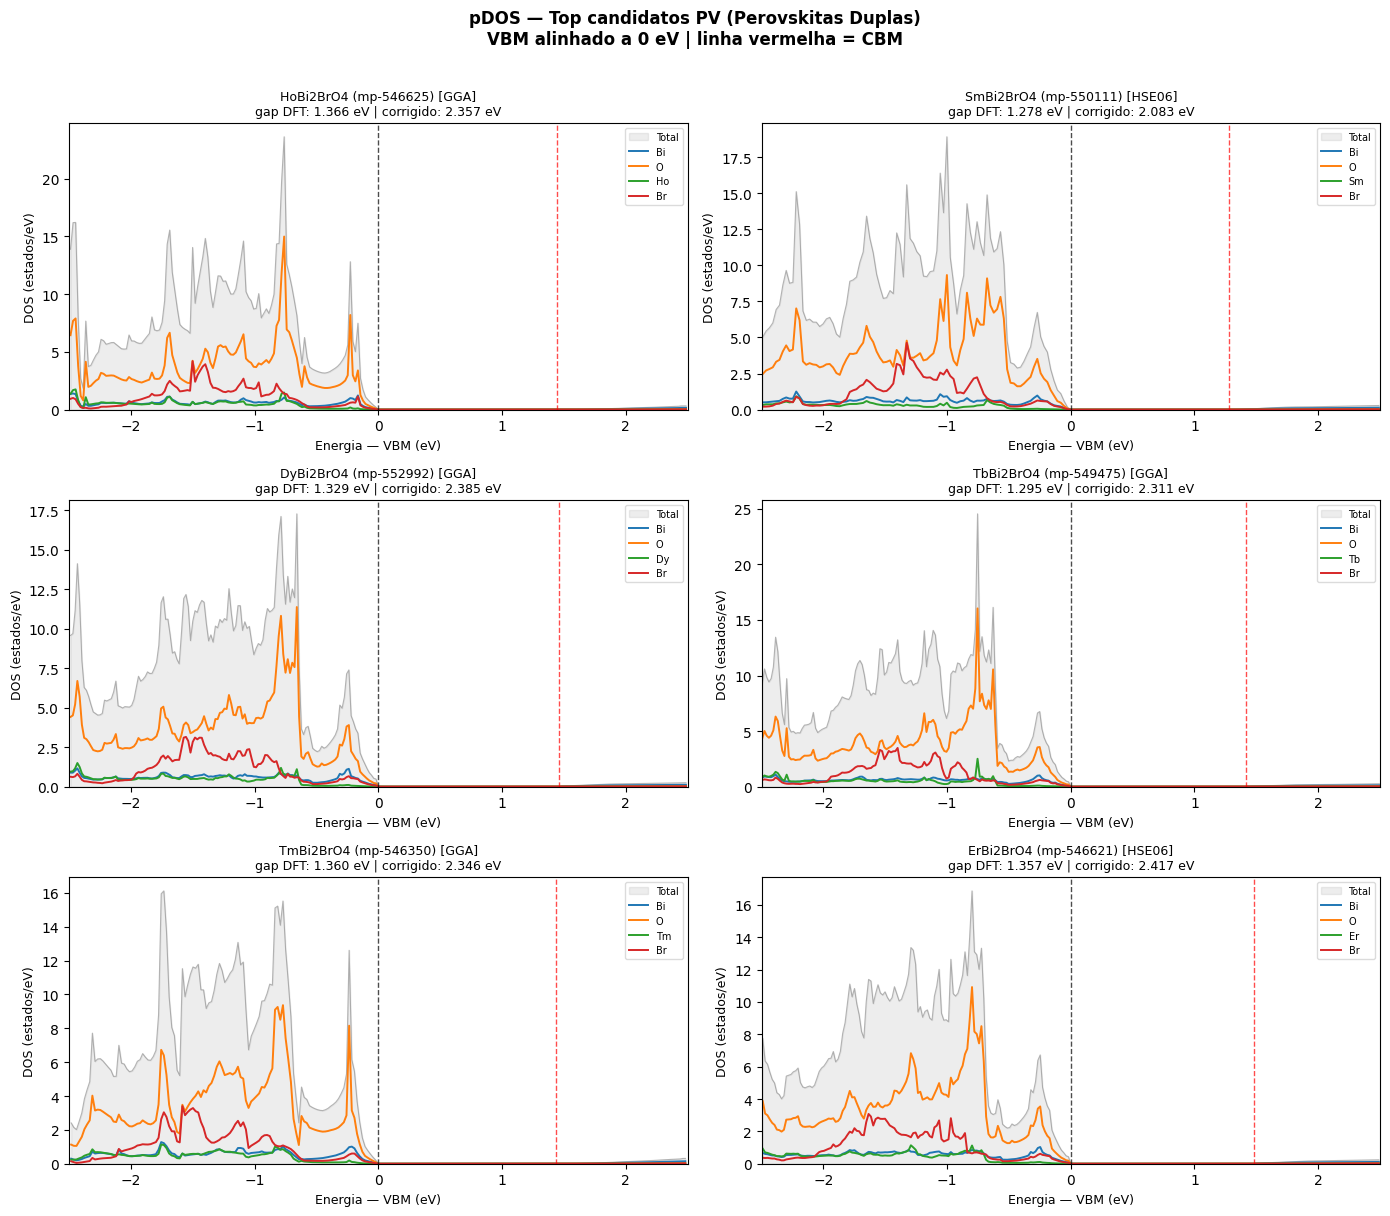

Figura salva: fig_pdos_pv.pdf


In [14]:
# ── Figura: pDOS dos top candidatos PV ─────────────────────────────────────
# Grade N×2: cada painel = um candidato; orbital s/p/d/f empilhados

candidatos_validos = [mid for mid in dos_pv_cache if mid in
                       df_info_pv[df_info_pv.get('gap_dos', pd.Series()).notna()]
                       ['material_id'].tolist()]

# Reconstruir com apenas os bem-sucedidos
candidatos_validos = [row['material_id'] for _, row in df_info_pv.iterrows()
                      if 'gap_dos' in row and not pd.isna(row.get('gap_dos'))]

n_plots = len(candidatos_validos)
ncols = 2
nrows = (n_plots + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows),
                          sharey=False, sharex=False)
axes = axes.flatten()

JANELA_PLOT = 2.5  # eV ao redor do gap

for i, mid in enumerate(candidatos_validos):
    ax = axes[i]
    cdos = dos_pv_cache[mid]
    row_info = df_info_pv[df_info_pv['material_id'] == mid].iloc[0]

    vbm = cdos.get_cbm_vbm()[1]
    cbm_val = cdos.get_cbm_vbm()[0]
    energias = cdos.energies - vbm
    mask = (energias >= -JANELA_PLOT) & (energias <= JANELA_PLOT)
    en = energias[mask]

    # DOS total
    dens_total = cdos.densities[Spin.up][mask]
    if Spin.down in cdos.densities:
        dens_total = dens_total + cdos.densities[Spin.down][mask]

    ax.fill_between(en, dens_total, alpha=0.15,
                    color=CORES_ORBITAL['total'], label='Total')
    ax.plot(en, dens_total, color=CORES_ORBITAL['total'],
            linewidth=0.8, alpha=0.6)

    # pDOS por elemento e orbital — focar nos elementos relevantes
    # Para REB₂XO₄: Bi, O, haleto, terra-rara
    elementos_plot = ['Bi', 'O']
    # Adicionar terra-rara se presente
    elementos_plot += row_info.get('elementos_tr', [])
    # Adicionar haleto se identificável (Br, Cl, I, F)
    for haleto in ['Br', 'Cl', 'I', 'F']:
        if haleto in row_info['formula']:
            elementos_plot.append(haleto)
            break

    cores_elem = plt.cm.tab10.colors
    for j, el_str in enumerate(elementos_plot[:5]):  # max 5 elementos
        try:
            el = Element(el_str)
            spd = cdos.get_element_spd_dos(el)
            dens_el = np.zeros(mask.sum())
            for orb_tipo in [OrbitalType.s, OrbitalType.p,
                              OrbitalType.d, OrbitalType.f]:
                if orb_tipo in spd:
                    d = spd[orb_tipo].densities[Spin.up][mask]
                    if Spin.down in spd[orb_tipo].densities:
                        d += spd[orb_tipo].densities[Spin.down][mask]
                    dens_el += d
            ax.plot(en, dens_el, color=cores_elem[j],
                    linewidth=1.4, label=el_str)
        except Exception:
            pass

    # Linha vertical no VBM e CBM
    ax.axvline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.7)
    ax.axvline(cbm_val - vbm, color='red', linewidth=1.0,
               linestyle='--', alpha=0.7)

    # Aviso estados 4f
    if row_info.get('estados_4f_gap', False):
        ax.text(0.05, 0.93, '⚠ estados 4f no gap (artefato GGA)',
                transform=ax.transAxes, fontsize=8,
                color='darkorange', va='top')

    regime_label = f" [{row_info.get('regime', 'GGA')}]"
    ax.set_title(f"{row_info['formula']} ({mid}){regime_label}\n"
                 f"gap DFT: {row_info['gap_dft']:.3f} eV | "
                 f"corrigido: {row_info.get('gap_corrigido','?'):.3f} eV",
                 fontsize=9)
    ax.set_xlabel('Energia — VBM (eV)', fontsize=9)
    ax.set_ylabel('DOS (estados/eV)', fontsize=9)
    ax.set_xlim(-JANELA_PLOT, JANELA_PLOT)
    ax.legend(fontsize=7, loc='upper right', framealpha=0.7)
    ax.set_ylim(bottom=0)

# Remover painéis excedentes
for k in range(n_plots, len(axes)):
    axes[k].set_visible(False)

fig.suptitle('pDOS — Top candidatos PV (Perovskitas Duplas)\n'
             'VBM alinhado a 0 eV | linha vermelha = CBM',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_pdos_pv.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: fig_pdos_pv.pdf')

---
# Seção 4 — Análise DOS — Candidatos IBSC

**Foco:** identificação de estados eletrônicos dentro do gap.  
O mecanismo IBSC (Luque & Martí 1997) requer uma banda intermediária
parcialmente preenchida dentro do gap do material hospedeiro.

**Critérios de análise:**
- Presença de estados isolados dentro do gap (entre VBM+0.1 eV e CBM-0.1 eV)
- Caráter orbital: estados d de metais de transição são fisicamente motivados
- Caráter f: artefato GGA — sinalizar explicitamente
- Separação gap hospedeiro (E_VBM→E_IB) e gap superior (E_IB→E_CBM)

**Nota sobre candidatos GGA+U (Mn/Fe/Co/V):**  
CsZnFeF₆, CsMnVF₆, CsVFeF₆, Na₂VNiF₇ — o parâmetro U aplicado afeta
diretamente a posição dos estados d. Reportar o U utilizado pelo MP
e sinalizar que a posição da banda intermediária depende do U.

In [15]:
# ── Extração de DOS e análise de estados no gap — candidatos IBSC ────────────

N_TOP_IBSC = 8  # mais amplo que PV pois diversidade composicional maior

# IBSC: ordenar por probabilidade calibrada (ou por gap_dft se não disponível)
col_ordem = 'proba_ibsc_calibrado' if 'proba_ibsc_calibrado' in df_ibsc_dos.columns \
            else 'band_gap'
top_ibsc = df_ibsc_dos.nlargest(N_TOP_IBSC, col_ordem).reset_index(drop=True)

dos_ibsc_cache = {}
info_ibsc = []

def analisar_estados_no_gap(cdos: CompleteDos,
                              limiar: float = 0.05) -> dict:
    """
    Quantifica estados dentro do gap por orbital.
    Retorna:
      - tem_estados: bool
      - caráter_dominante: 's'/'p'/'d'/'f'
      - posicao_pico: posição do pico máximo relativa ao VBM (eV)
      - integracao: integral da DOS dentro do gap (estados/célula)
    """
    vbm = cdos.get_cbm_vbm()[1]
    cbm_val = cdos.get_cbm_vbm()[0]
    energias = cdos.energies - vbm
    gap = cbm_val - vbm

    # Margem para evitar bordas do gap
    margem = min(0.1, gap * 0.1)
    mask_gap = (energias > margem) & (energias < gap - margem)

    resultado = {
        'gap_host': round(gap, 4),
        'tem_estados': False,
        'carater_dominante': None,
        'posicao_pico_eV': None,
        'integracao': 0.0
    }

    if mask_gap.sum() == 0:
        return resultado

    dens_total = cdos.densities[Spin.up][mask_gap]
    if Spin.down in cdos.densities:
        dens_total = dens_total + cdos.densities[Spin.down][mask_gap]

    integracao = float(np.trapz(dens_total, energias[mask_gap]))
    resultado['integracao'] = round(integracao, 4)

    if np.any(dens_total > limiar):
        resultado['tem_estados'] = True
        idx_pico = np.argmax(dens_total)
        resultado['posicao_pico_eV'] = round(
            float(energias[mask_gap][idx_pico]), 3)

        # Identificar orbital dominante
        contrib = {}
        for el in cdos.structure.composition.elements:
            spd = cdos.get_element_spd_dos(el)
            for orb_tipo, nome in [
                (OrbitalType.s, 's'), (OrbitalType.p, 'p'),
                (OrbitalType.d, 'd'), (OrbitalType.f, 'f')
            ]:
                if orb_tipo in spd:
                    d = spd[orb_tipo].densities[Spin.up][mask_gap]
                    if Spin.down in spd[orb_tipo].densities:
                        d += spd[orb_tipo].densities[Spin.down][mask_gap]
                    chave = f'{el.symbol}-{nome}'
                    contrib[chave] = float(np.trapz(d, energias[mask_gap]))

        if contrib:
            dominante = max(contrib, key=contrib.get)
            resultado['carater_dominante'] = dominante
            resultado['contrib_orbitais'] = {
                k: round(v, 4) for k, v in
                sorted(contrib.items(), key=lambda x: -x[1])[:5]
            }

    return resultado


with MPRester(MP_API_KEY) as mpr:
    for _, row in top_ibsc.iterrows():
        mid = row['material_id']
        formula = row.get('formula', mid)
        print(f'  Extraindo DOS: {mid} ({formula})...', end=' ')
        try:
            cdos = mpr.get_dos_by_material_id(mid)
            dos_ibsc_cache[mid] = cdos

            analise = analisar_estados_no_gap(cdos, LIMIAR_ESTADOS_GAP)
            els_tr = get_elementos_terra_rara(str(formula))
            estados_4f = detectar_estados_4f_no_gap(cdos, els_tr)

            info_ibsc.append({
                'material_id':       mid,
                'formula':           formula,
                'gap_dft':           row.get('band_gap', None),
                'regime':            row.get('regime_calc', 'GGA'),
                'hull':              row.get('energy_above_hull', 0.0),
                'is_gap_direct':     row.get('is_gap_direct', None),
                **analise,
                'estados_4f_gap':    any(estados_4f.values()),
                'gap_corrigido_est': round(
                    analise['gap_host'] * FATOR_CORRECAO_GGA_PD, 3)
            })

            flag = ''
            if analise['tem_estados']:
                flag = f" | IB em {analise['posicao_pico_eV']:.2f} eV " \
                       f"[{analise.get('carater_dominante','?')}]"
            if any(estados_4f.values()):
                flag += ' ⚠ 4f'
            print(f"OK — gap: {analise['gap_host']:.3f} eV{flag}")

        except Exception as e:
            print(f'ERRO: {e}')

df_info_ibsc = pd.DataFrame(info_ibsc)
print()
cols_show = ['material_id','formula','gap_dft','gap_host',
             'tem_estados','carater_dominante','posicao_pico_eV',
             'estados_4f_gap','regime']
cols_show = [c for c in cols_show if c in df_info_ibsc.columns]
print(df_info_ibsc[cols_show].to_string(index=False))

  Extraindo DOS: mp-10234 (Sr2BN2F)... 

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

OK — gap: 2.566 eV
  Extraindo DOS: mp-1110566 (Cs2NaAsBr6)... 

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

OK — gap: 2.559 eV
  Extraindo DOS: mp-1191842 (Na2VNiF7)... 

...

OK — gap: 2.606 eV
  Extraindo DOS: mp-1112117 (Cs2RbScI6)... 

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

OK — gap: 2.393 eV
  Extraindo DOS: mp-559481 (BaVClO3)... 

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

OK — gap: 2.375 eV

material_id    formula  gap_dft  gap_host  tem_estados carater_dominante posicao_pico_eV  estados_4f_gap regime
   mp-10234    Sr2BN2F   2.5675    2.5661        False              None            None           False    GGA
 mp-1110566 Cs2NaAsBr6   2.5590    2.5590        False              None            None           False    GGA
 mp-1191842   Na2VNiF7   2.4654    2.4350        False              None            None           False  GGA+U
  mp-560959   KTl2MoF6   2.4401    2.4364        False              None            None           False  GGA+U
 mp-1110609  Rb2GaAgF6   2.4254    2.4234        False              None            None           False    GGA
  mp-989550 Rb2TlInCl6   2.3962    2.6061        False              None            None           False    GGA
 mp-1112117  Cs2RbScI6   2.3929    2.3929        False              None            None           False    GGA
  mp-559481    BaVClO3   2.3925    2.3750        False              None            

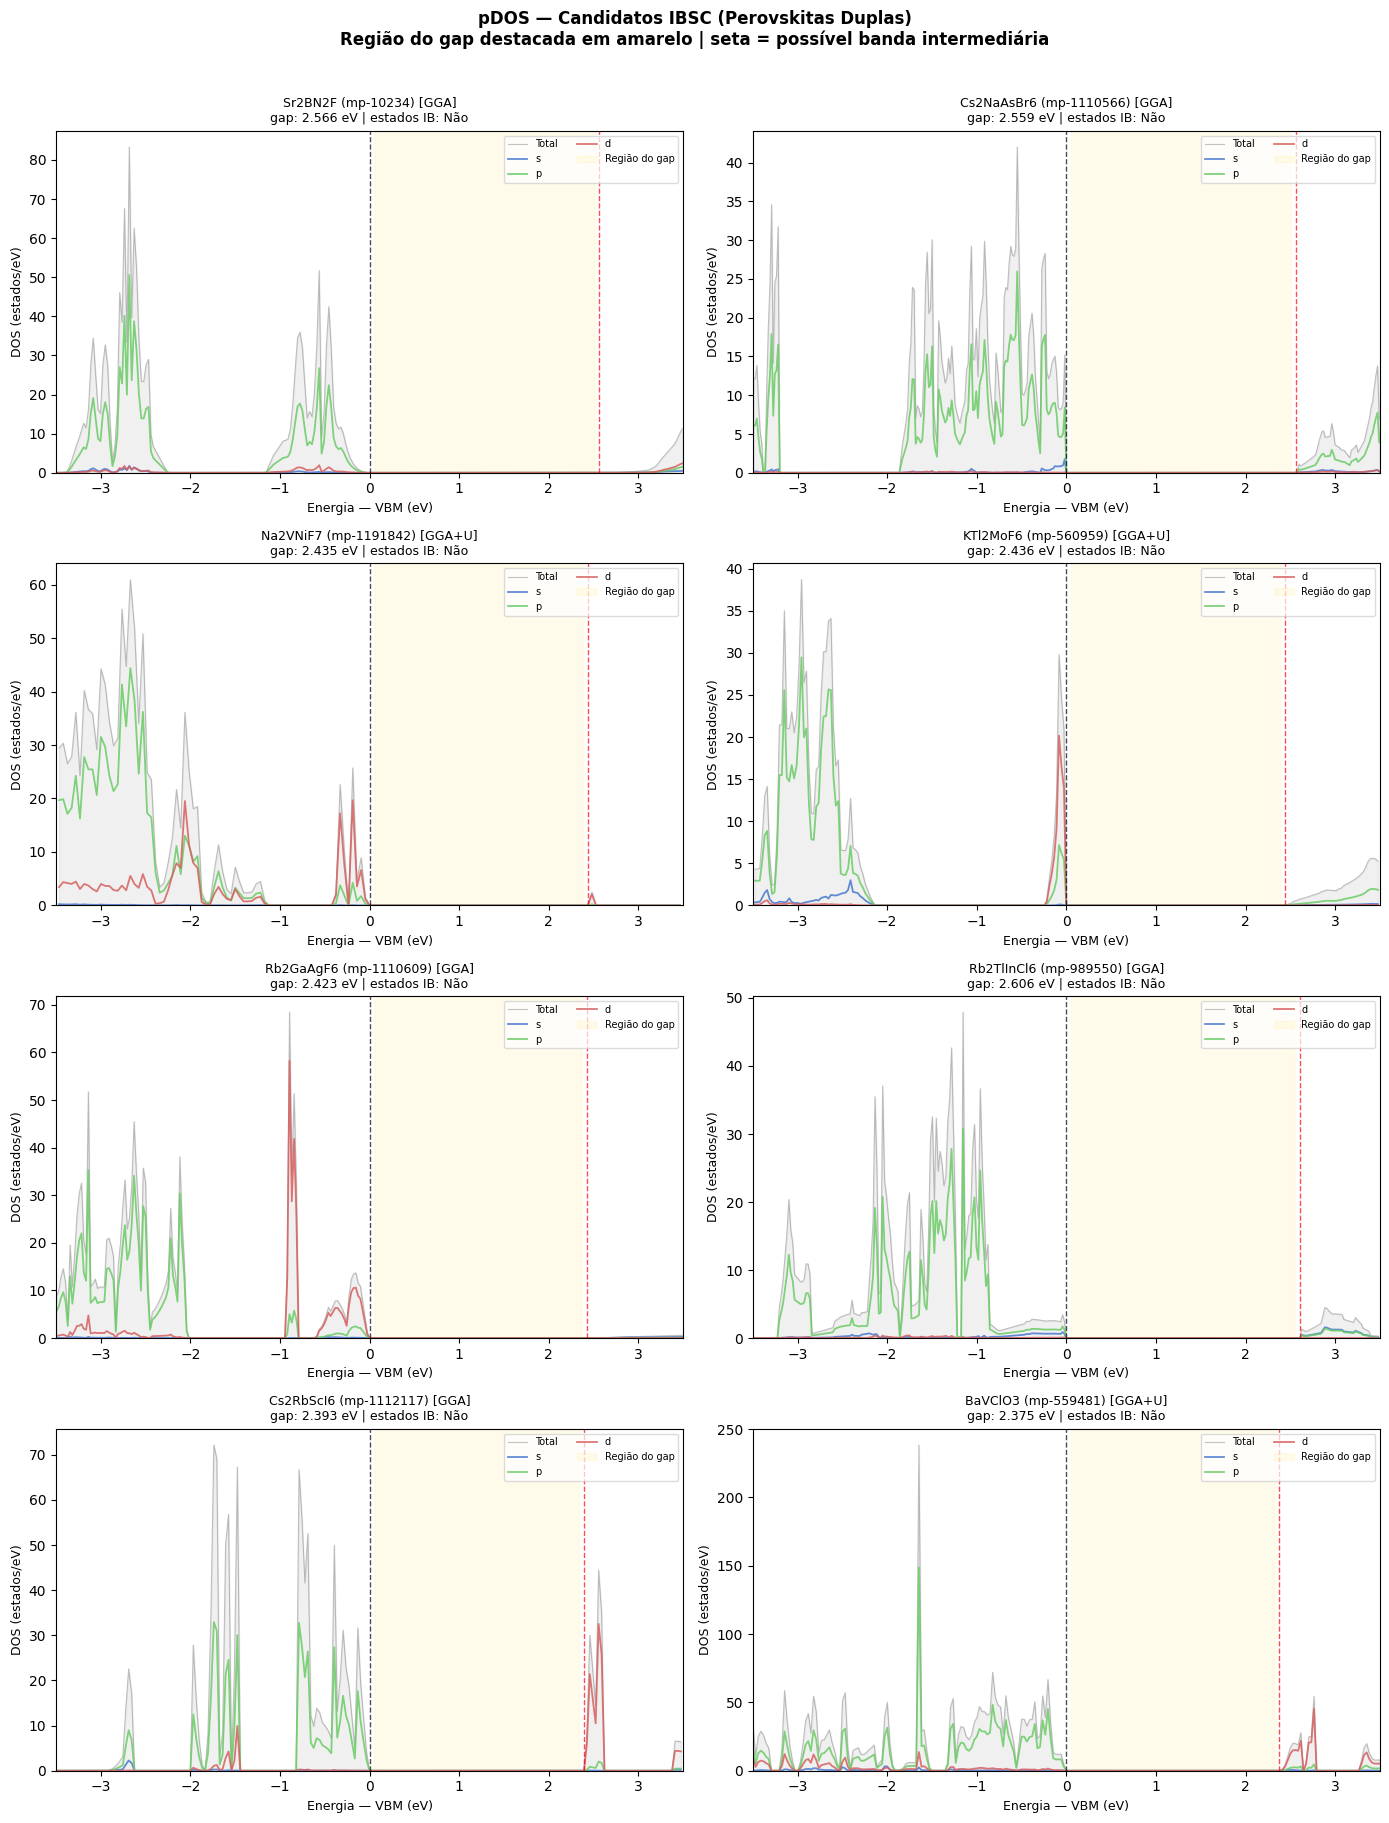

Figura salva: fig_pdos_ibsc.pdf


In [16]:
# ── Figura: pDOS candidatos IBSC — destaque nos estados dentro do gap ────────

mids_ibsc_validos = [r['material_id'] for _, r in df_info_ibsc.iterrows()
                     if 'gap_host' in r and not pd.isna(r.get('gap_host'))]

n_plots_ibsc = len(mids_ibsc_validos)
ncols_i = 2
nrows_i = (n_plots_ibsc + 1) // ncols_i

fig2, axes2 = plt.subplots(nrows_i, ncols_i, figsize=(14, 4.5 * nrows_i))
axes2 = axes2.flatten()

JANELA_IBSC_PLOT = 3.5

for i, mid in enumerate(mids_ibsc_validos):
    ax = axes2[i]
    cdos = dos_ibsc_cache[mid]
    row_info = df_info_ibsc[df_info_ibsc['material_id'] == mid].iloc[0]

    vbm = cdos.get_cbm_vbm()[1]
    cbm_val = cdos.get_cbm_vbm()[0]
    gap = cbm_val - vbm
    energias = cdos.energies - vbm
    mask = (energias >= -JANELA_IBSC_PLOT) & (energias <= JANELA_IBSC_PLOT)
    en = energias[mask]

    dens_total = cdos.densities[Spin.up][mask]
    if Spin.down in cdos.densities:
        dens_total = dens_total + cdos.densities[Spin.down][mask]

    ax.fill_between(en, dens_total, alpha=0.12,
                    color=CORES_ORBITAL['total'])
    ax.plot(en, dens_total, color=CORES_ORBITAL['total'],
            linewidth=0.8, alpha=0.5, label='Total')

    # pDOS por orbital agregado (s, p, d, f)
    for orb_tipo, nome, cor in [
        (OrbitalType.s, 's', CORES_ORBITAL['s']),
        (OrbitalType.p, 'p', CORES_ORBITAL['p']),
        (OrbitalType.d, 'd', CORES_ORBITAL['d']),
        (OrbitalType.f, 'f', CORES_ORBITAL['f'])
    ]:
        dens_orb = np.zeros(mask.sum())
        for el in cdos.structure.composition.elements:
            spd = cdos.get_element_spd_dos(el)
            if orb_tipo in spd:
                d = spd[orb_tipo].densities[Spin.up][mask]
                if Spin.down in spd[orb_tipo].densities:
                    d += spd[orb_tipo].densities[Spin.down][mask]
                dens_orb += d
        if np.max(dens_orb) > 0.01:
            ax.plot(en, dens_orb, color=cor, linewidth=1.3,
                    alpha=0.85, label=nome)

    # Destacar região do gap
    ax.axvspan(0.05, gap - 0.05, alpha=0.08, color='gold',
               label='Região do gap')

    ax.axvline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.7)
    ax.axvline(gap, color='red', linewidth=1.0, linestyle='--', alpha=0.7)

    # Seta para estados dentro do gap
    if row_info.get('tem_estados') and row_info.get('posicao_pico_eV'):
        pos = row_info['posicao_pico_eV']
        ax.annotate(
            f"IB?\n{pos:.2f} eV",
            xy=(pos, 0.1), xytext=(pos + 0.4, 0.5),
            arrowprops=dict(arrowstyle='->', color='darkred'),
            fontsize=8, color='darkred'
        )

    if row_info.get('estados_4f_gap'):
        ax.text(0.05, 0.93, '⚠ estados 4f no gap (artefato GGA)',
                transform=ax.transAxes, fontsize=8,
                color='darkorange', va='top')

    regime_label = f" [{row_info.get('regime','GGA')}]"
    ax.set_title(
        f"{row_info['formula']} ({mid}){regime_label}\n"
        f"gap: {row_info.get('gap_host','?'):.3f} eV | "
        f"estados IB: {'Sim' if row_info.get('tem_estados') else 'Não'}",
        fontsize=9
    )
    ax.set_xlabel('Energia — VBM (eV)', fontsize=9)
    ax.set_ylabel('DOS (estados/eV)', fontsize=9)
    ax.set_xlim(-JANELA_IBSC_PLOT, JANELA_IBSC_PLOT)
    ax.legend(fontsize=7, ncol=2, loc='upper right', framealpha=0.7)
    ax.set_ylim(bottom=0)

for k in range(n_plots_ibsc, len(axes2)):
    axes2[k].set_visible(False)

fig2.suptitle('pDOS — Candidatos IBSC (Perovskitas Duplas)\n'
              'Região do gap destacada em amarelo | seta = possível banda intermediária',
              fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_pdos_ibsc.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: fig_pdos_ibsc.pdf')

---
# Seção 5 — Correção empírica gap DFT → experimental

**Referência principal:** Cs₂AgBiBr₆ — DFT 1.35 eV → experimental 2.2 eV → fator ~1.63  
**Limitação crítica:** o fator não é uniforme entre compostos — varia com composição,
haleto e metal de transição presente. Usar *apenas* como estimativa de ordem de grandeza.

**Para os candidatos com HSE06 no MP** (SmBi₂BrO₄, ErBi₂ClO₄, TmBi₂IO₄, TbBi₂ClO₄):
o gap HSE06 é mais próximo do experimental — usar diretamente sem fator de correção.

In [17]:
# ── Correção de gap e estimativa experimental ────────────────────────────────

# Consolidar todos os candidatos analisados
df_todos = pd.concat([
    df_info_pv.assign(janela='PV'),
    df_info_ibsc.assign(janela='IBSC')
], ignore_index=True)

def gap_estimado(row):
    """
    Retorna gap estimado experimental:
    - HSE06: usar gap_dos diretamente (mais próximo do experimental)
    - GGA/GGA+U: aplicar fator de correção empírico
    Inclui nota de incerteza.
    """
    gap = row.get('gap_dos', row.get('gap_dft', np.nan))
    if pd.isna(gap):
        return np.nan, 'N/A'

    regime = str(row.get('regime', 'GGA'))
    if 'HSE' in regime:
        return round(gap, 3), 'HSE06 (direto)'
    else:
        return round(gap * FATOR_CORRECAO_GGA_PD, 3), f'GGA×{FATOR_CORRECAO_GGA_PD}'


df_todos[['gap_exp_estimado', 'metodo_correcao']] = df_todos.apply(
    lambda r: pd.Series(gap_estimado(r)), axis=1
)

# Verificar se gap corrigido cai na janela experimental correta
def na_janela_corrigida(row):
    g = row['gap_exp_estimado']
    j = row['janela']
    if pd.isna(g):
        return 'N/A'
    if j == 'PV':
        return 'Sim' if JANELA_PV_CORR_MIN <= g <= JANELA_PV_CORR_MAX else 'Fora'
    else:
        return 'Sim' if JANELA_IBSC_CORR_MIN <= g <= JANELA_IBSC_CORR_MAX else 'Fora'

df_todos['na_janela_exp'] = df_todos.apply(na_janela_corrigida, axis=1)

print('── Estimativa de gap experimental ──────────────────────────────────────')
cols = ['formula','janela','gap_dft','gap_dos','gap_exp_estimado',
        'metodo_correcao','na_janela_exp','regime']
cols = [c for c in cols if c in df_todos.columns]
print(df_todos[cols].to_string(index=False))

n_pv_confirmado  = (df_todos[df_todos['janela']=='PV']['na_janela_exp']=='Sim').sum()
n_ibsc_confirmado = (df_todos[df_todos['janela']=='IBSC']['na_janela_exp']=='Sim').sum()
print(f'\nCandidatos PV na janela experimental (1.0–1.8 eV): {n_pv_confirmado}')
print(f'Candidatos IBSC na janela experimental (1.8–2.6 eV): {n_ibsc_confirmado}')

── Estimativa de gap experimental ──────────────────────────────────────
   formula janela  gap_dft  gap_dos  gap_exp_estimado metodo_correcao na_janela_exp regime
 HoBi2BrO4     PV   1.3665   1.4462             2.357        GGA×1.63          Fora    GGA
 SmBi2BrO4     PV   1.2783   1.2780             1.278  HSE06 (direto)           Sim  HSE06
 DyBi2BrO4     PV   1.3290   1.4633             2.385        GGA×1.63          Fora    GGA
 TbBi2BrO4     PV   1.2946   1.4176             2.311        GGA×1.63          Fora    GGA
 TmBi2BrO4     PV   1.3602   1.4393             2.346        GGA×1.63          Fora    GGA
 ErBi2BrO4     PV   1.3570   1.4827             1.483  HSE06 (direto)           Sim  HSE06
   Sr2BN2F   IBSC   2.5675      NaN               NaN             N/A           N/A    GGA
Cs2NaAsBr6   IBSC   2.5590      NaN               NaN             N/A           N/A    GGA
  Na2VNiF7   IBSC   2.4654      NaN               NaN             N/A           N/A  GGA+U
  KTl2MoF6   IBSC

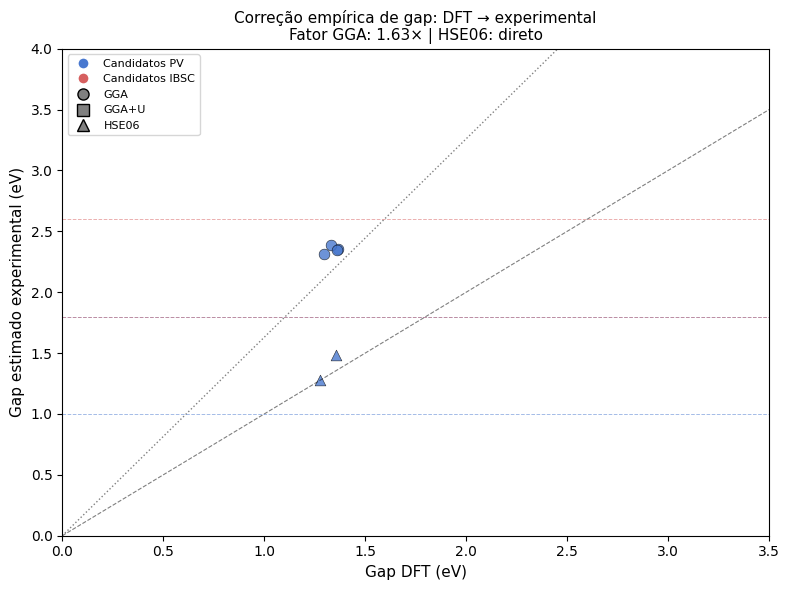

Figura salva: fig_correcao_gap.pdf


In [18]:
# ── Figura: gap DFT vs gap estimado experimental ─────────────────────────────

fig3, ax3 = plt.subplots(figsize=(8, 6))

cores_janela = {'PV': '#4878CF', 'IBSC': '#D65F5F'}
marcadores_regime = {'GGA': 'o', 'GGA+U': 's', 'HSE06': '^'}

for _, row in df_todos.dropna(subset=['gap_dft','gap_exp_estimado']).iterrows():
    cor = cores_janela.get(row['janela'], 'gray')
    mk = marcadores_regime.get(str(row.get('regime','GGA')).split('_')[0], 'o')
    ax3.scatter(row['gap_dft'], row['gap_exp_estimado'],
                color=cor, marker=mk, s=60, alpha=0.8, edgecolors='k',
                linewidths=0.4)

# Linha y = x (sem correção) e y = fator*x
g_range = np.linspace(0, 3.5, 100)
ax3.plot(g_range, g_range, 'k--', linewidth=0.8, alpha=0.5, label='Sem correção (y=x)')
ax3.plot(g_range, g_range * FATOR_CORRECAO_GGA_PD, 'gray',
         linewidth=1.0, linestyle=':', label=f'Fator {FATOR_CORRECAO_GGA_PD}×')

# Linhas de janelas experimentais
for lim, cor, label in [
    (JANELA_PV_CORR_MIN,   '#4878CF', 'PV min (1.0 eV)'),
    (JANELA_PV_CORR_MAX,   '#4878CF', 'PV max (1.8 eV)'),
    (JANELA_IBSC_CORR_MIN, '#D65F5F', 'IBSC min (1.8 eV)'),
    (JANELA_IBSC_CORR_MAX, '#D65F5F', 'IBSC max (2.6 eV)')
]:
    ax3.axhline(lim, color=cor, linewidth=0.7, linestyle='--', alpha=0.5)

# Legenda manual
legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#4878CF',
           markersize=8, label='Candidatos PV'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#D65F5F',
           markersize=8, label='Candidatos IBSC'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
           markersize=8, markeredgecolor='k', label='GGA'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='gray',
           markersize=8, markeredgecolor='k', label='GGA+U'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='gray',
           markersize=8, markeredgecolor='k', label='HSE06'),
]
ax3.legend(handles=legend_els, fontsize=8, loc='upper left')

ax3.set_xlabel('Gap DFT (eV)', fontsize=11)
ax3.set_ylabel('Gap estimado experimental (eV)', fontsize=11)
ax3.set_title('Correção empírica de gap: DFT → experimental\n'
              f'Fator GGA: {FATOR_CORRECAO_GGA_PD}× | HSE06: direto', fontsize=11)
ax3.set_xlim(0, 3.5)
ax3.set_ylim(0, 4.0)
plt.tight_layout()
plt.savefig('fig_correcao_gap.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: fig_correcao_gap.pdf')

---
# Seção 6 — Estrutura de Bandas — Top 5 candidatos por janela

A estrutura de bandas complementa a DOS com informação sobre dispersão:
- Gap direto vs indireto confirmado (mais preciso que `is_gap_direct`)
- Curvatura das bandas (massa efetiva) — proxy de mobilidade de portadores
- Degenerescência no VBM e CBM

**Cobertura no MP:** menor que DOS — verificar individualmente.  
Prioridade: candidatos sem flag de estados 4f no gap e calculados com HSE06.

In [19]:
# ── Estrutura de bandas — top 5 PV (priorizando HSE06 e sem flag 4f) ─────────

from pymatgen.electronic_structure.plotter import BSPlotter

# Priorizar: HSE06 > sem estados 4f > maior probabilidade calibrada
def score_prioridade(row):
    score = 0
    if str(row.get('regime', '')).upper() == 'HSE06':
        score += 10
    if not row.get('estados_4f_gap', True):
        score += 5
    score += float(row.get('proba_pv', 0))
    return score

df_info_pv['score_prioridade'] = df_info_pv.apply(score_prioridade, axis=1)
top5_bs = df_info_pv.nlargest(5, 'score_prioridade')

bs_cache = {}

with MPRester(MP_API_KEY) as mpr:
    for _, row in top5_bs.iterrows():
        mid = row['material_id']
        print(f'  Band structure: {mid} ({row["formula"]})...', end=' ')
        try:
            bs = mpr.get_bandstructure_by_material_id(mid)
            if bs is not None:
                bs_cache[mid] = bs
                print(f'OK — gap direto: {bs.is_metal()} metal, '
                      f'gap: {bs.get_band_gap()["energy"]:.3f} eV')
            else:
                print('não disponível.')
        except Exception as e:
            print(f'ERRO: {e}')

print(f'\nBand structures obtidas: {len(bs_cache)}/{len(top5_bs)}')

  Band structure: mp-550111 (SmBi2BrO4)... 

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

OK — gap direto: False metal, gap: 1.278 eV
  Band structure: mp-546621 (ErBi2BrO4)... 

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

OK — gap direto: False metal, gap: 1.357 eV
  Band structure: mp-546625 (HoBi2BrO4)... 

...

OK — gap direto: False metal, gap: 1.366 eV
  Band structure: mp-552992 (DyBi2BrO4)... 

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

OK — gap direto: False metal, gap: 1.329 eV
  Band structure: mp-549475 (TbBi2BrO4)... 

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

OK — gap direto: False metal, gap: 1.295 eV

Band structures obtidas: 5/5


--- Subplot 1 ---
Material ID: mp-550111
Formula: SmBi2BrO4
Band Gap (from bs): 1.278 eV
Energy Data Hash: fd722f134b66da529a5dd18a6b5284f1
--- Subplot 2 ---
Material ID: mp-546621
Formula: ErBi2BrO4
Band Gap (from bs): 1.357 eV
Energy Data Hash: dd6939c25d00ce0cf334988b726600b0
--- Subplot 3 ---
Material ID: mp-546625
Formula: HoBi2BrO4
Band Gap (from bs): 1.366 eV
Energy Data Hash: b6e86b34cb348b02df6bc2b2753ad6e3
--- Subplot 4 ---
Material ID: mp-552992
Formula: DyBi2BrO4
Band Gap (from bs): 1.329 eV
Energy Data Hash: 219dab5f9e5ed3e7e697877ca52bd3de


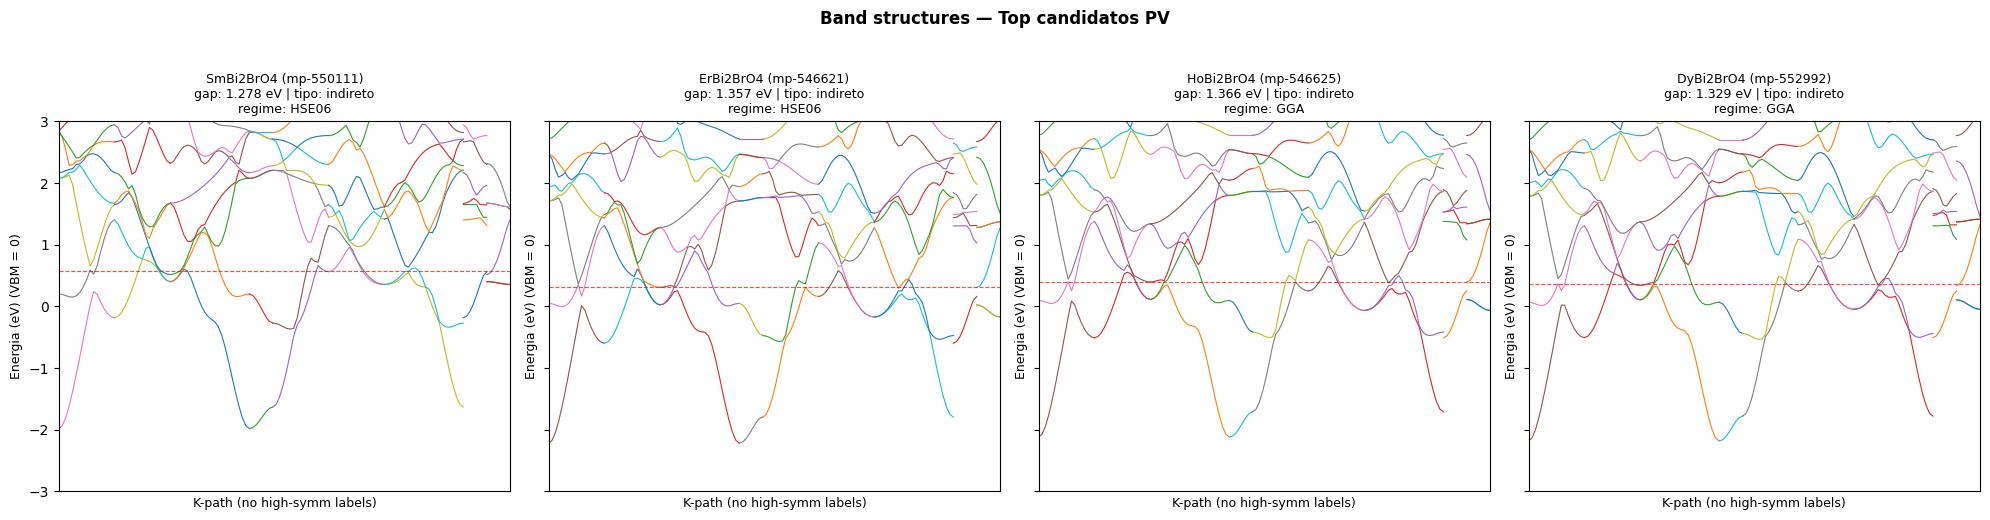

Figura de band structure consolidada salva: fig_bs_resumo.pdf


In [28]:
import hashlib
import numpy as np
# ── Plot das estruturas de bandas ────────────────────
# Plotar até 4 lado a lado para figura compacta do artigo

from pymatgen.electronic_structure.core import Spin

mids_bs = list(bs_cache.keys())[:4]
n_bs = len(mids_bs)

if n_bs == 0:
    print('Nenhuma band structure disponível para plotar.')
elif n_bs > 0:
    fig4, axes4 = plt.subplots(1, n_bs, figsize=(5 * n_bs, 5), sharey=True)
    if n_bs == 1:
        axes4 = [axes4] # Ensure axes4 is iterable even for a single plot

    for i, mid in enumerate(mids_bs):
        ax = axes4[i]
        bs = bs_cache[mid]
        row_info = df_info_pv[df_info_pv['material_id'] == mid].iloc[0]

        plotter = BSPlotter(bs)
        bs_data = plotter.bs_plot_data()

        # Debug prints to verify distinct data
        print(f"--- Subplot {i+1} ---")
        print(f"Material ID: {mid}")
        print(f"Formula: {row_info['formula']}")
        print(f"Band Gap (from bs): {bs.get_band_gap()['energy']:.3f} eV")

        # Create a hash of the energy data to check for identity
        all_energies = []
        for spin_key in bs_data['energy']:
            for segment_bands in bs_data['energy'][spin_key]:
                for band_energies_k_points in segment_bands:
                    all_energies.extend(band_energies_k_points)
        # Use np.array and tobytes() for consistent hashing of numerical data
        energy_hash = hashlib.md5(np.array(all_energies).tobytes()).hexdigest()
        print(f"Energy Data Hash: {energy_hash}")

        # Plot each band
        vbm_ref = bs.get_vbm()['energy'] # Get the VBM energy for normalization

        for j in range(len(bs_data['distances'])):
            distances = bs_data['distances'][j]
            for spin_key in bs_data['energy']:
                for band_energy in bs_data['energy'][spin_key][j]:
                    # Normalize band energies relative to VBM
                    ax.plot(distances, band_energy - vbm_ref, linewidth=0.8)

        # Mark VBM and CBM
        # Normalize VBM and CBM energies for plotting
        vbm_energy = (bs_data['vbm'][0][0] - vbm_ref) if len(bs_data['vbm']) > 0 else None
        cbm_energy = (bs_data['cbm'][0][0] - vbm_ref) if len(bs_data['cbm']) > 0 else None

        if vbm_energy is not None:
            ax.axhline(y=vbm_energy, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
        if cbm_energy is not None:
            ax.axhline(y=cbm_energy, color='green', linestyle='--', linewidth=0.8, alpha=0.7)

        # Set labels for high-symmetry points, only if 'labels_dict' is available
        if 'labels_dict' in bs_data and bs_data['labels_dict']:
            tick_locs = [bs_data['kpoints'][idx][0] for idx in bs_data['labels_dict'].values()]
            tick_labels = list(bs_data['labels_dict'].keys())
            ax.set_xticks(tick_locs)
            ax.set_xticklabels(tick_labels)

            # Draw vertical lines for high-symmetry points
            for t in tick_locs:
                ax.axvline(t, color='gray', linewidth=0.5, linestyle='-')
        else:
            ax.set_xticks([]) # Remove default ticks
            ax.set_xticklabels([])
            ax.set_xlabel('K-path (no high-symm labels)', fontsize=9)

        ax.set_ylabel('Energia (eV) (VBM = 0)', fontsize=9)
        ax.set_xlim(bs_data['distances'][0][0], bs_data['distances'][-1][-1])
        ax.set_ylim(-3, 3) # Consistent with original ylim

        # Add title and band gap info
        bg_info = bs.get_band_gap()
        ax.set_title(
            f"{row_info['formula']} ({mid})\n"
            f"gap: {bg_info['energy']:.3f} eV | tipo: {'direto' if bg_info['direct'] else 'indireto'}\n"
            f"regime: {row_info.get('regime','GGA')}",
            fontsize=9
        )

    fig4.suptitle('Band structures — Top candidatos PV', fontsize=12, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig('fig_bs_resumo.pdf', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figura de band structure consolidada salva: fig_bs_resumo.pdf')

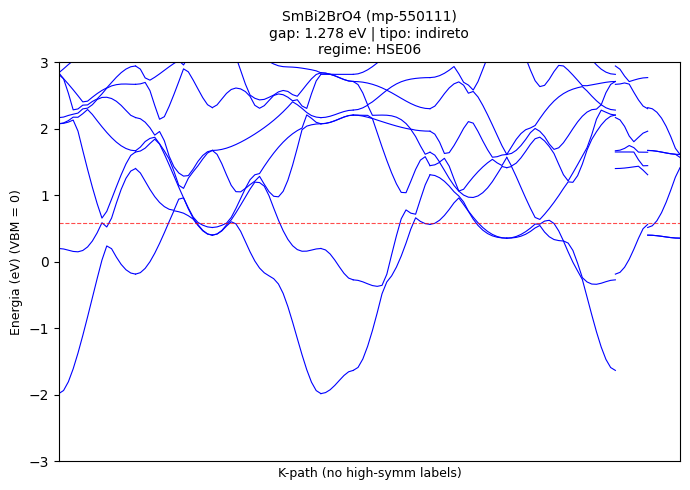

Band structure para SmBi2BrO4 (mp-550111) exibida.


In [29]:
from pymatgen.electronic_structure.plotter import BSPlotter

mids_bs = list(bs_cache.keys())

if mids_bs:
    first_mid = mids_bs[0]
    bs = bs_cache[first_mid]
    row_info = df_info_pv[df_info_pv['material_id'] == first_mid].iloc[0]

    fig, ax = plt.subplots(figsize=(7, 5))

    plotter = BSPlotter(bs)
    bs_data = plotter.bs_plot_data()

    # Normalize to VBM = 0
    vbm_ref = bs.get_vbm()['energy']

    for j in range(len(bs_data['distances'])):
        distances = bs_data['distances'][j]
        for spin_key in bs_data['energy']:
            for band_energy in bs_data['energy'][spin_key][j]:
                ax.plot(distances, band_energy - vbm_ref, linewidth=0.8, color='blue') # Single color as requested

    # Mark VBM and CBM
    vbm_energy = (bs_data['vbm'][0][0] - vbm_ref) if len(bs_data['vbm']) > 0 else None
    cbm_energy = (bs_data['cbm'][0][0] - vbm_ref) if len(bs_data['cbm']) > 0 else None

    if vbm_energy is not None:
        ax.axhline(y=vbm_energy, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    if cbm_energy is not None:
        ax.axhline(y=cbm_energy, color='green', linestyle='--', linewidth=0.8, alpha=0.7)

    # Set labels for high-symmetry points
    if 'labels_dict' in bs_data and bs_data['labels_dict']:
        tick_locs = [bs_data['kpoints'][idx][0] for idx in bs_data['labels_dict'].values()]
        tick_labels = list(bs_data['labels_dict'].keys())
        ax.set_xticks(tick_locs)
        ax.set_xticklabels(tick_labels)

        for t in tick_locs:
            ax.axvline(t, color='gray', linewidth=0.5, linestyle='-')
    else:
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_xlabel('K-path (no high-symm labels)', fontsize=9)

    ax.set_ylabel('Energia (eV) (VBM = 0)', fontsize=9)
    ax.set_xlim(bs_data['distances'][0][0], bs_data['distances'][-1][-1])
    ax.set_ylim(-3, 3)

    bg_info = bs.get_band_gap()
    ax.set_title(
        f"{row_info['formula']} ({first_mid})\n"
        f"gap: {bg_info['energy']:.3f} eV | tipo: {'direto' if bg_info['direct'] else 'indireto'}\n"
        f"regime: {row_info.get('regime','GGA')}",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()
    print(f"Band structure para {row_info['formula']} ({first_mid}) exibida.")
else:
    print("Nenhuma band structure disponível no cache para plotar.")

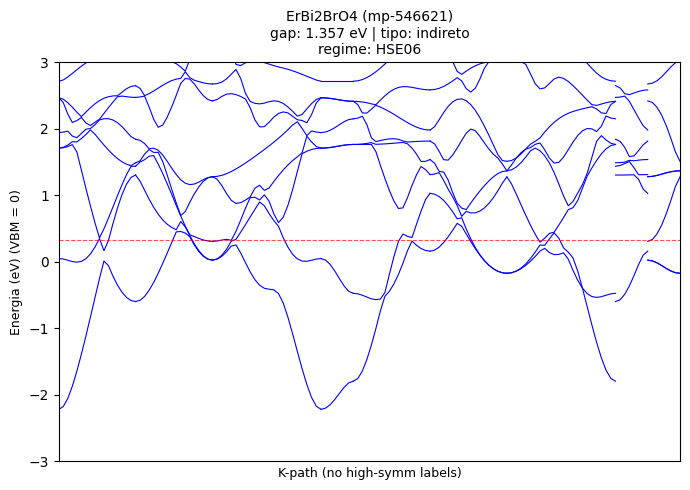

Band structure para ErBi2BrO4 (mp-546621) exibida.


In [30]:
from pymatgen.electronic_structure.plotter import BSPlotter

mids_bs = list(bs_cache.keys())

if len(mids_bs) > 1:
    second_mid = mids_bs[1]
    bs = bs_cache[second_mid]
    row_info = df_info_pv[df_info_pv['material_id'] == second_mid].iloc[0]

    fig, ax = plt.subplots(figsize=(7, 5))

    plotter = BSPlotter(bs)
    bs_data = plotter.bs_plot_data()

    # Normalize to VBM = 0
    vbm_ref = bs.get_vbm()['energy']

    for j in range(len(bs_data['distances'])):
        distances = bs_data['distances'][j]
        for spin_key in bs_data['energy']:
            for band_energy in bs_data['energy'][spin_key][j]:
                ax.plot(distances, band_energy - vbm_ref, linewidth=0.8, color='blue') # Single color as requested

    # Mark VBM and CBM
    vbm_energy = (bs_data['vbm'][0][0] - vbm_ref) if len(bs_data['vbm']) > 0 else None
    cbm_energy = (bs_data['cbm'][0][0] - vbm_ref) if len(bs_data['cbm']) > 0 else None

    if vbm_energy is not None:
        ax.axhline(y=vbm_energy, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    if cbm_energy is not None:
        ax.axhline(y=cbm_energy, color='green', linestyle='--', linewidth=0.8, alpha=0.7)

    # Set labels for high-symmetry points
    if 'labels_dict' in bs_data and bs_data['labels_dict']:
        tick_locs = [bs_data['kpoints'][idx][0] for idx in bs_data['labels_dict'].values()]
        tick_labels = list(bs_data['labels_dict'].keys())
        ax.set_xticks(tick_locs)
        ax.set_xticklabels(tick_labels)

        for t in tick_locs:
            ax.axvline(t, color='gray', linewidth=0.5, linestyle='-')
    else:
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.set_xlabel('K-path (no high-symm labels)', fontsize=9)

    ax.set_ylabel('Energia (eV) (VBM = 0)', fontsize=9)
    ax.set_xlim(bs_data['distances'][0][0], bs_data['distances'][-1][-1])
    ax.set_ylim(-3, 3)

    bg_info = bs.get_band_gap()
    ax.set_title(
        f"{row_info['formula']} ({second_mid})\n"
        f"gap: {bg_info['energy']:.3f} eV | tipo: {'direto' if bg_info['direct'] else 'indireto'}\n"
        f"regime: {row_info.get('regime','GGA')}",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()
    print(f"Band structure para {row_info['formula']} ({second_mid}) exibida.")
else:
    print("Não há segundo material no cache de band structures para plotar.")

---
# Seção 7 — Tabela final consolidada para o artigo

Tabela que integra todas as informações das Fases 1–4 para os candidatos finais.  
Esta é a tabela principal do artigo — deve ter informação suficiente para que
o leitor possa priorizar candidatos para síntese ou cálculos adicionais.

In [32]:
# ── Tabela final consolidada ─────────────────────────────────────────────────

# PV
df_final_pv = df_todos[df_todos['janela'] == 'PV'].copy()
df_final_pv['aplicacao'] = 'PV'

# IBSC — adicionar flag de estados dentro do gap
df_final_ibsc = df_todos[df_todos['janela'] == 'IBSC'].copy()
df_final_ibsc['aplicacao'] = 'IBSC'

df_final = pd.concat([df_final_pv, df_final_ibsc], ignore_index=True)

# Adicionar coluna de alerta para o revisor
def gerar_alertas(row):
    alertas = []
    if row.get('estados_4f_gap'):
        alertas.append('estados 4f no gap (artefato GGA)')
    if str(row.get('regime', '')).upper() == 'GGA+U':
        alertas.append('GGA+U: posição estados d depende do parâmetro U')
    if row.get('na_janela_exp') == 'Fora':
        alertas.append('gap corrigido fora da janela experimental')
    if not row.get('is_gap_direct', True):
        alertas.append('gap indireto')
    return '; '.join(alertas) if alertas else '—'

df_final['alertas'] = df_final.apply(gerar_alertas, axis=1)

# Selecionar e renomear colunas para a tabela do artigo
colunas_artigo = [
    'material_id', 'formula', 'aplicacao', 'regime',
    'gap_dft', 'gap_exp_estimado', 'na_janela_exp',
    'hull', 'is_gap_direct',
    'tem_estados',       # relevante para IBSC
    'carater_dominante', # relevante para IBSC
    'alertas'
]
colunas_artigo = [c for c in colunas_artigo if c in df_final.columns]

df_tabela = df_final[colunas_artigo].sort_values(
    ['aplicacao', 'na_janela_exp', 'hull']
).reset_index(drop=True)

print('══ Tabela final consolidada ══')
print(df_tabela.to_string(index=False))

# Exportar
import os
os.makedirs('data/fase4', exist_ok=True) # Ensure the directory exists
df_tabela.to_csv('data/fase4/tabela_final_candidatos.csv', index=False)
print('\nExportado: data/fase4/tabela_final_candidatos.csv')

══ Tabela final consolidada ══
material_id    formula aplicacao regime  gap_dft  gap_exp_estimado na_janela_exp  hull  is_gap_direct tem_estados carater_dominante                                                       alertas
   mp-10234    Sr2BN2F      IBSC    GGA   2.5675               NaN           N/A   0.0           True       False              None                                                             —
 mp-1110566 Cs2NaAsBr6      IBSC    GGA   2.5590               NaN           N/A   0.0          False       False              None                                                  gap indireto
 mp-1191842   Na2VNiF7      IBSC  GGA+U   2.4654               NaN           N/A   0.0           True       False              None               GGA+U: posição estados d depende do parâmetro U
  mp-560959   KTl2MoF6      IBSC  GGA+U   2.4401               NaN           N/A   0.0           True       False              None               GGA+U: posição estados d depende do parâmetro U

In [33]:
# ── Resumo executivo para o artigo ──────────────────────────────────────────

print('══ RESUMO EXECUTIVO — Fase 4 ══════════════════════════════════════════')
print()

# Candidatos PV
pv_tab = df_tabela[df_tabela['aplicacao'] == 'PV']
print(f'── Candidatos PV')
print(f'   Total analisados:                {len(pv_tab)}')
if 'na_janela_exp' in pv_tab.columns:
    print(f'   Na janela 1.0–1.8 eV (corrigido): '
          f"{(pv_tab['na_janela_exp']=='Sim').sum()}")
if 'estados_4f_gap' in pv_tab.columns:
    print(f'   Com flag estados 4f no gap:        '
          f"{pv_tab['estados_4f_gap'].sum() if 'estados_4f_gap' in pv_tab.columns else 'N/A'}")
if 'is_gap_direct' in pv_tab.columns:
    n_dir = pv_tab['is_gap_direct'].sum()
    print(f'   Gap direto:                        {n_dir} / {len(pv_tab)}')
print()

# Candidatos IBSC
ibsc_tab = df_tabela[df_tabela['aplicacao'] == 'IBSC']
print(f'── Candidatos IBSC')
print(f'   Total analisados:                    {len(ibsc_tab)}')
if 'na_janela_exp' in ibsc_tab.columns:
    print(f'   Na janela 1.8–2.6 eV (corrigido):     '
          f"{(ibsc_tab['na_janela_exp']=='Sim').sum()}")
if 'tem_estados' in ibsc_tab.columns:
    print(f'   Com estados detectados no gap (DOS):  '
          f"{ibsc_tab['tem_estados'].sum() if 'tem_estados' in ibsc_tab.columns else 'N/A'}")
if 'estados_4f_gap' in ibsc_tab.columns:
    print(f'   Com flag estados 4f no gap:           '
          f"{ibsc_tab['estados_4f_gap'].sum() if 'estados_4f_gap' in ibsc_tab.columns else 'N/A'}")
print()

print('── Figuras geradas')
print('   fig_pdos_pv.pdf          — pDOS top candidatos PV')
print('   fig_pdos_ibsc.pdf        — pDOS candidatos IBSC com destaque no gap')
print('   fig_correcao_gap.pdf     — gap DFT vs estimativa experimental')
print('   fig_bs_*.pdf             — estrutura de bandas (top 4 PV)')
print()
print('── Limitações a reportar no artigo')
print('   1. Estados 4f de terras-raras dentro do gap são artefatos GGA')
print('   2. Fator de correção GGA→exp (1.63×) é aproximado e não uniforme')
print('   3. Posição de estados d em GGA+U depende do parâmetro U aplicado')
print('   4. Verificação definitiva requer cálculos HSE06 ou GW')
print()
print('── Próximos passos sugeridos (trabalhos futuros)')
print('   - Cálculos HSE06 para os top 5–10 candidatos PV sem flag 4f')
print('   - Verificação de estabilidade dinâmica (fônons) para candidatos hull=0')
print('   - Revisão de estado magnético para Mn/Fe/Co com gap=0 em GGA+U')
print('   - Triagem estrutural secundária do conjunto "outra" das kesteritas')

══ RESUMO EXECUTIVO — Fase 4 ══════════════════════════════════════════

── Candidatos PV
   Total analisados:                6
   Na janela 1.0–1.8 eV (corrigido): 2
   Gap direto:                        0 / 6

── Candidatos IBSC
   Total analisados:                    8
   Na janela 1.8–2.6 eV (corrigido):     0
   Com estados detectados no gap (DOS):  0

── Figuras geradas
   fig_pdos_pv.pdf          — pDOS top candidatos PV
   fig_pdos_ibsc.pdf        — pDOS candidatos IBSC com destaque no gap
   fig_correcao_gap.pdf     — gap DFT vs estimativa experimental
   fig_bs_*.pdf             — estrutura de bandas (top 4 PV)

── Limitações a reportar no artigo
   1. Estados 4f de terras-raras dentro do gap são artefatos GGA
   2. Fator de correção GGA→exp (1.63×) é aproximado e não uniforme
   3. Posição de estados d em GGA+U depende do parâmetro U aplicado
   4. Verificação definitiva requer cálculos HSE06 ou GW

── Próximos passos sugeridos (trabalhos futuros)
   - Cálculos HSE06 para os

In [34]:
# ── Resumo executivo para o artigo ──────────────────────────────────────────

print('══ RESUMO EXECUTIVO — Fase 4 ══════════════════════════════════════════')
print()

# Candidatos PV
pv_tab = df_tabela[df_tabela['aplicacao'] == 'PV']
print(f'── Candidatos PV')
print(f'   Total analisados:                {len(pv_tab)}')
if 'na_janela_exp' in pv_tab.columns:
    print(f'   Na janela 1.0–1.8 eV (corrigido): '
          f"{(pv_tab['na_janela_exp']=='Sim').sum()}")
if 'estados_4f_gap' in pv_tab.columns:
    print(f'   Com flag estados 4f no gap:        '
          f"{pv_tab['estados_4f_gap'].sum() if 'estados_4f_gap' in pv_tab.columns else 'N/A'}")
if 'is_gap_direct' in pv_tab.columns:
    n_dir = pv_tab['is_gap_direct'].sum()
    print(f'   Gap direto:                        {n_dir} / {len(pv_tab)}')
print()

# Candidatos IBSC
ibsc_tab = df_tabela[df_tabela['aplicacao'] == 'IBSC']
print(f'── Candidatos IBSC')
print(f'   Total analisados:                    {len(ibsc_tab)}')
if 'na_janela_exp' in ibsc_tab.columns:
    print(f'   Na janela 1.8–2.6 eV (corrigido):     '
          f"{(ibsc_tab['na_janela_exp']=='Sim').sum()}")
if 'tem_estados' in ibsc_tab.columns:
    print(f'   Com estados detectados no gap (DOS):  '
          f"{ibsc_tab['tem_estados'].sum() if 'tem_estados' in ibsc_tab.columns else 'N/A'}")
if 'estados_4f_gap' in ibsc_tab.columns:
    print(f'   Com flag estados 4f no gap:           '
          f"{ibsc_tab['estados_4f_gap'].sum() if 'estados_4f_gap' in ibsc_tab.columns else 'N/A'}")
print()

print('── Figuras geradas')
print('   fig_pdos_pv.pdf          — pDOS top candidatos PV')
print('   fig_pdos_ibsc.pdf        — pDOS candidatos IBSC com destaque no gap')
print('   fig_correcao_gap.pdf     — gap DFT vs estimativa experimental')
print('   fig_bs_*.pdf             — estrutura de bandas (top 4 PV)')
print()
print('── Limitações a reportar no artigo')
print('   1. Estados 4f de terras-raras dentro do gap são artefatos GGA')
print('   2. Fator de correção GGA→exp (1.63×) é aproximado e não uniforme')
print('   3. Posição de estados d em GGA+U depende do parâmetro U aplicado')
print('   4. Verificação definitiva requer cálculos HSE06 ou GW')
print()
print('── Próximos passos sugeridos (trabalhos futuros)')
print('   - Cálculos HSE06 para os top 5–10 candidatos PV sem flag 4f')
print('   - Verificação de estabilidade dinâmica (fônons) para candidatos hull=0')
print('   - Revisão de estado magnético para Mn/Fe/Co com gap=0 em GGA+U')
print('   - Triagem estrutural secundária do conjunto "outra" das kesteritas')

══ RESUMO EXECUTIVO — Fase 4 ══════════════════════════════════════════

── Candidatos PV
   Total analisados:                6
   Na janela 1.0–1.8 eV (corrigido): 2
   Gap direto:                        0 / 6

── Candidatos IBSC
   Total analisados:                    8
   Na janela 1.8–2.6 eV (corrigido):     0
   Com estados detectados no gap (DOS):  0

── Figuras geradas
   fig_pdos_pv.pdf          — pDOS top candidatos PV
   fig_pdos_ibsc.pdf        — pDOS candidatos IBSC com destaque no gap
   fig_correcao_gap.pdf     — gap DFT vs estimativa experimental
   fig_bs_*.pdf             — estrutura de bandas (top 4 PV)

── Limitações a reportar no artigo
   1. Estados 4f de terras-raras dentro do gap são artefatos GGA
   2. Fator de correção GGA→exp (1.63×) é aproximado e não uniforme
   3. Posição de estados d em GGA+U depende do parâmetro U aplicado
   4. Verificação definitiva requer cálculos HSE06 ou GW

── Próximos passos sugeridos (trabalhos futuros)
   - Cálculos HSE06 para os

---

## Nota final de versionamento

Este notebook corresponde à **Fase 4** do pipeline documentado em `02_decisoes_metodologicas.md`.  
Todas as decisões metodológicas desta fase estão registradas naquele arquivo.

**Arquivos gerados:**
- `data/fase4/tabela_final_candidatos.csv` — tabela consolidada para o artigo
- `fig_pdos_pv.pdf` — figura 4a do artigo
- `fig_pdos_ibsc.pdf` — figura 4b do artigo
- `fig_correcao_gap.pdf` — figura suplementar
- `fig_bs_*.pdf` — figuras suplementares de band structure

**Referências centrais desta fase:**
- Shockley & Queisser (1961) — janela PV 1.0–1.8 eV
- Luque & Martí (1997) — conceito IBSC, janela 1.8–2.6 eV
- Materials Project (Jain et al., 2013) — fonte dos dados DFT
- pymatgen (Ong et al., 2013) — análise de DOS e band structure